<a href="https://www.kaggle.com/code/lalit7881/phishing-email-detection-2026-eda-100?scriptVersionId=323345544" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prince7489/phishing-email-detection-2026-dataset/phishing_email_detection_2026_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/prince7489/phishing-email-detection-2026-dataset/phishing_email_detection_2026_dataset.csv")

In [3]:
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1


In [4]:
df.tail()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
1495,1496,villabrian@gmail.com,Claim Your Reward Now,1,1,8,7,113,1
1496,1497,lharvey@gmail.com,Urgent Account Verification,1,0,8,5,50,1
1497,1498,xjennings@outlook.com,Suspicious Login Attempt,0,0,8,10,82,1
1498,1499,paulcobb@paypal-alert.com,Suspicious Login Attempt,1,0,7,9,36,1
1499,1500,kristen14@company-secure.com,Invoice Attached,0,1,4,0,161,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   email_id            1500 non-null   int64 
 1   sender_email        1500 non-null   object
 2   subject             1500 non-null   object
 3   has_link            1500 non-null   int64 
 4   has_attachment      1500 non-null   int64 
 5   urgency_score       1500 non-null   int64 
 6   spelling_errors     1500 non-null   int64 
 7   email_length_words  1500 non-null   int64 
 8   is_phishing         1500 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 105.6+ KB


In [6]:
df.describe()

,email_id,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,0.629333,0.512667,5.722667,3.708000,132.559333,0.493333
std,433.157015,0.483144,0.500006,3.002182,3.209819,79.315970,0.500122
min,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.000000
25%,375.750000,0.000000,0.000000,3.000000,1.000000,72.000000,0.000000
50%,750.500000,1.000000,1.000000,5.000000,2.000000,108.000000,0.000000
75%,1125.250000,1.000000,1.000000,8.000000,6.000000,193.000000,1.000000
max,1500.000000,1.000000,1.000000,10.000000,10.000000,300.000000,1.000000


In [7]:
df.isnull().sum()

email_id              0
sender_email          0
subject               0
has_link              0
has_attachment        0
urgency_score         0
spelling_errors       0
email_length_words    0
is_phishing           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

email_id               int64
sender_email          object
subject               object
has_link               int64
has_attachment         int64
urgency_score          int64
spelling_errors        int64
email_length_words     int64
is_phishing            int64
dtype: object

In [10]:
df.shape

(1500, 9)

In [11]:
df.columns

Index(['email_id', 'sender_email', 'subject', 'has_link', 'has_attachment',
       'urgency_score', 'spelling_errors', 'email_length_words',
       'is_phishing'],
      dtype='object')

In [12]:
df.nunique()

email_id              1500
sender_email          1499
subject                 10
has_link                 2
has_attachment           2
urgency_score            9
spelling_errors         11
email_length_words     276
is_phishing              2
dtype: int64

## EDA

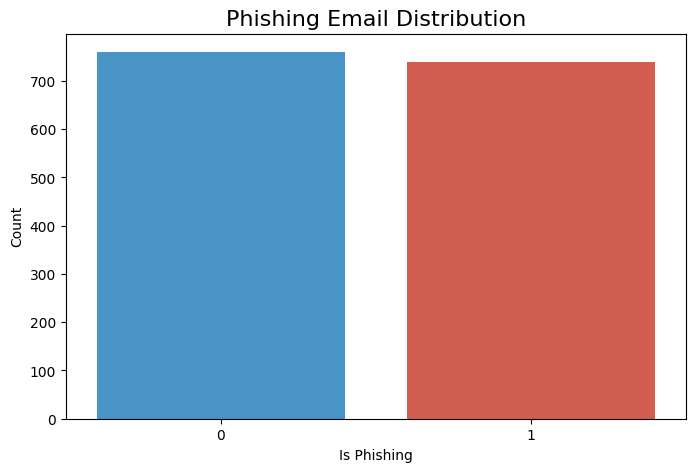

In [13]:
plt.figure(figsize=(8,5))

colors = ['#3498db', '#e74c3c']

sns.countplot(
    data=df,
    x='is_phishing',
    palette=colors
)

plt.title('Phishing Email Distribution', fontsize=16)
plt.xlabel('Is Phishing')
plt.ylabel('Count')
plt.show()

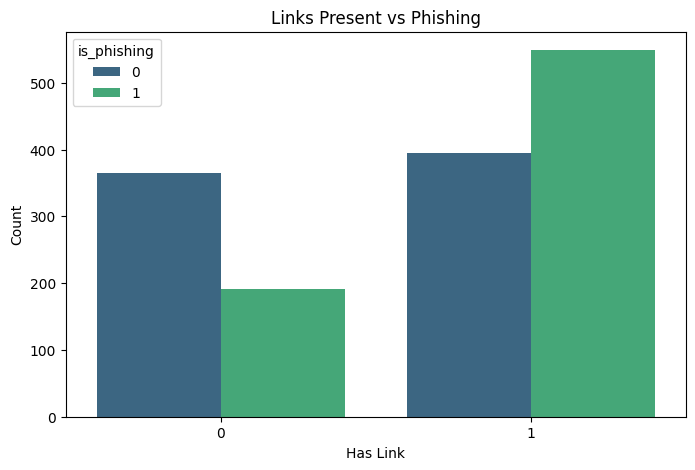

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='has_link',
    hue='is_phishing',
    palette='viridis'
)

plt.title('Links Present vs Phishing')
plt.xlabel('Has Link')
plt.ylabel('Count')
plt.show()

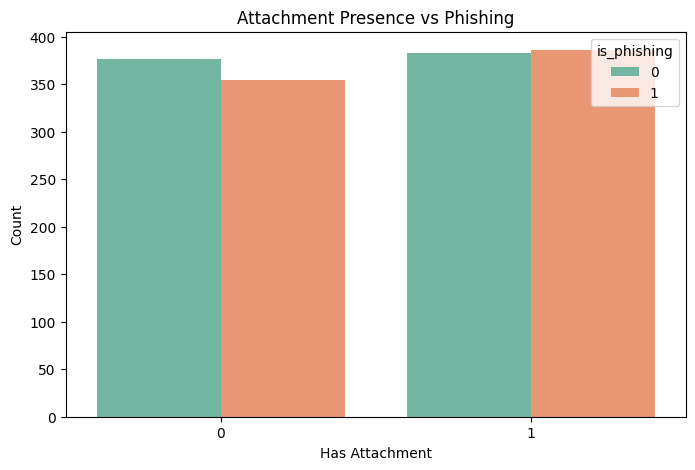

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='has_attachment',
    hue='is_phishing',
    palette='Set2'
)

plt.title('Attachment Presence vs Phishing')
plt.xlabel('Has Attachment')
plt.ylabel('Count')
plt.show()

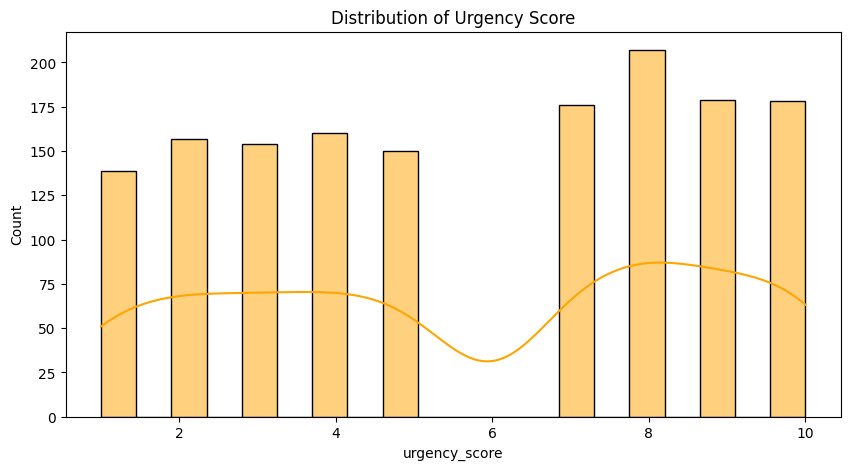

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='urgency_score',
    kde=True,
    color='orange',
    bins=20
)

plt.title('Distribution of Urgency Score')
plt.show()

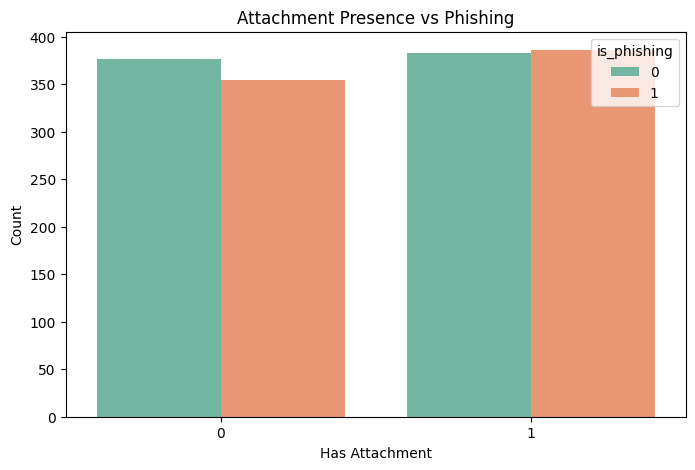

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='has_attachment',
    hue='is_phishing',
    palette='Set2'
)

plt.title('Attachment Presence vs Phishing')
plt.xlabel('Has Attachment')
plt.ylabel('Count')
plt.show()

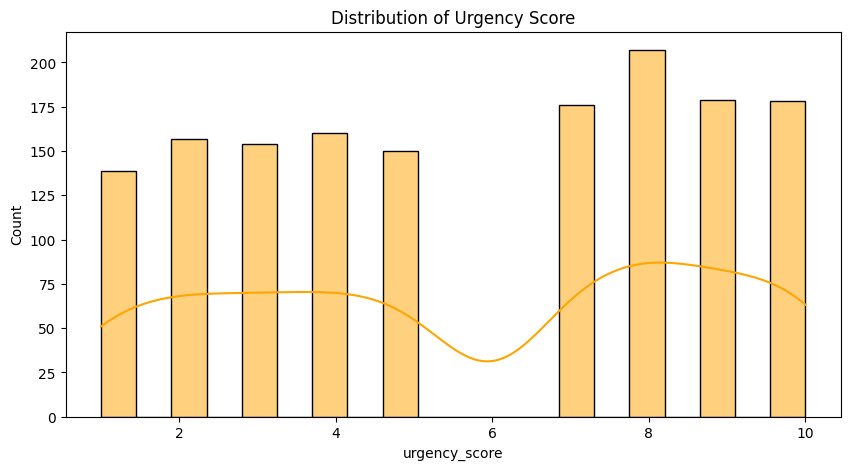

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='urgency_score',
    kde=True,
    color='orange',
    bins=20
)

plt.title('Distribution of Urgency Score')
plt.show()

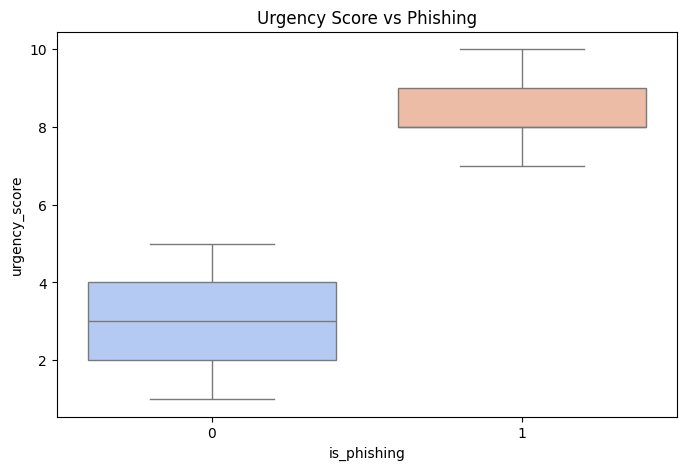

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_phishing',
    y='urgency_score',
    palette='coolwarm'
)

plt.title('Urgency Score vs Phishing')
plt.show()

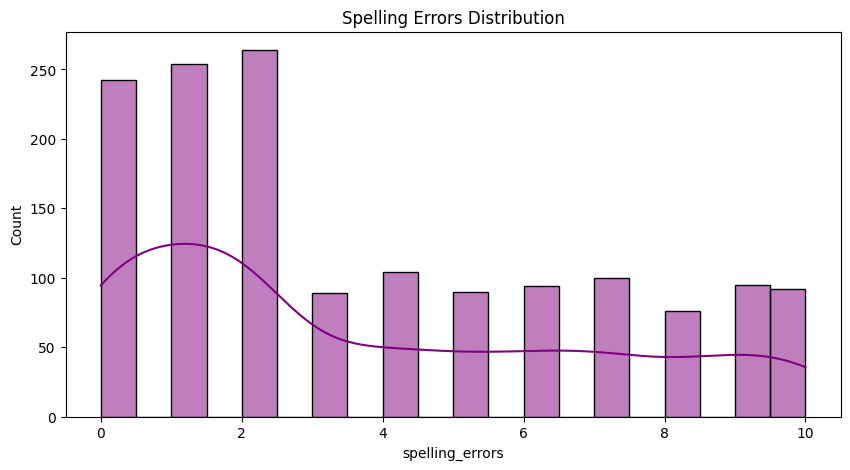

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['spelling_errors'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title('Spelling Errors Distribution')
plt.show()

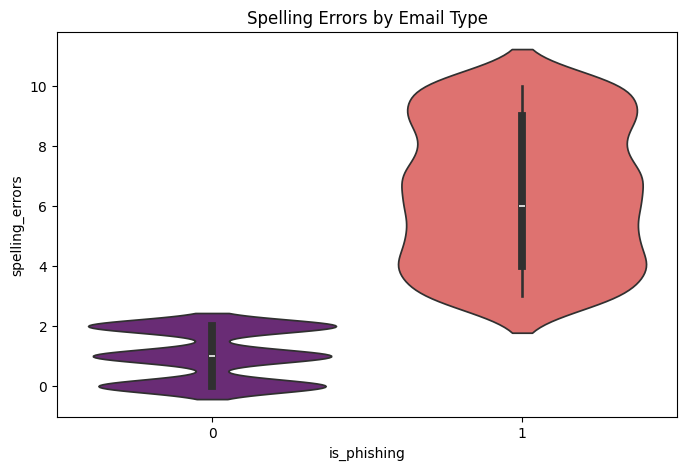

In [21]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='is_phishing',
    y='spelling_errors',
    palette='magma'
)

plt.title('Spelling Errors by Email Type')
plt.show()

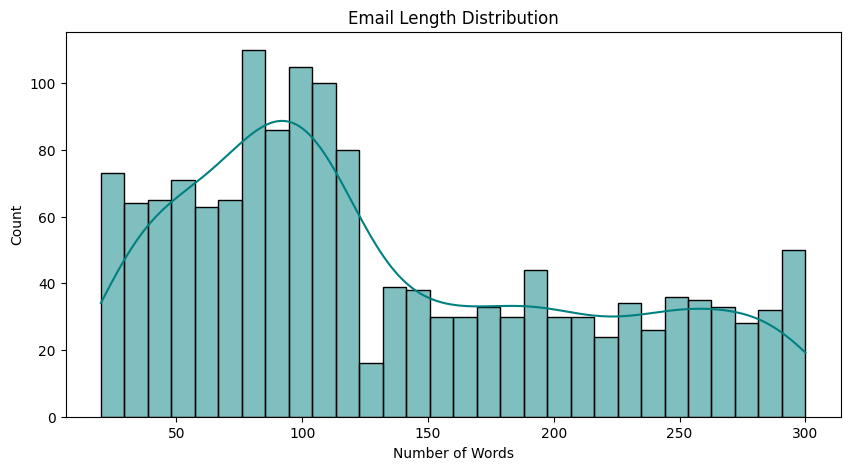

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['email_length_words'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title('Email Length Distribution')
plt.xlabel('Number of Words')
plt.show()

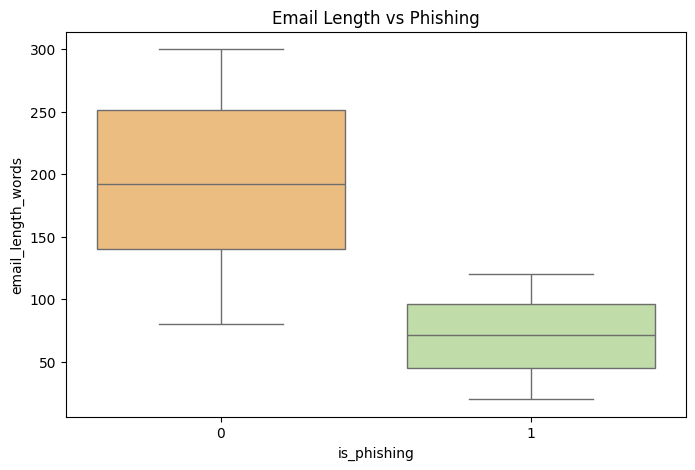

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_phishing',
    y='email_length_words',
    palette='Spectral'
)

plt.title('Email Length vs Phishing')
plt.show()

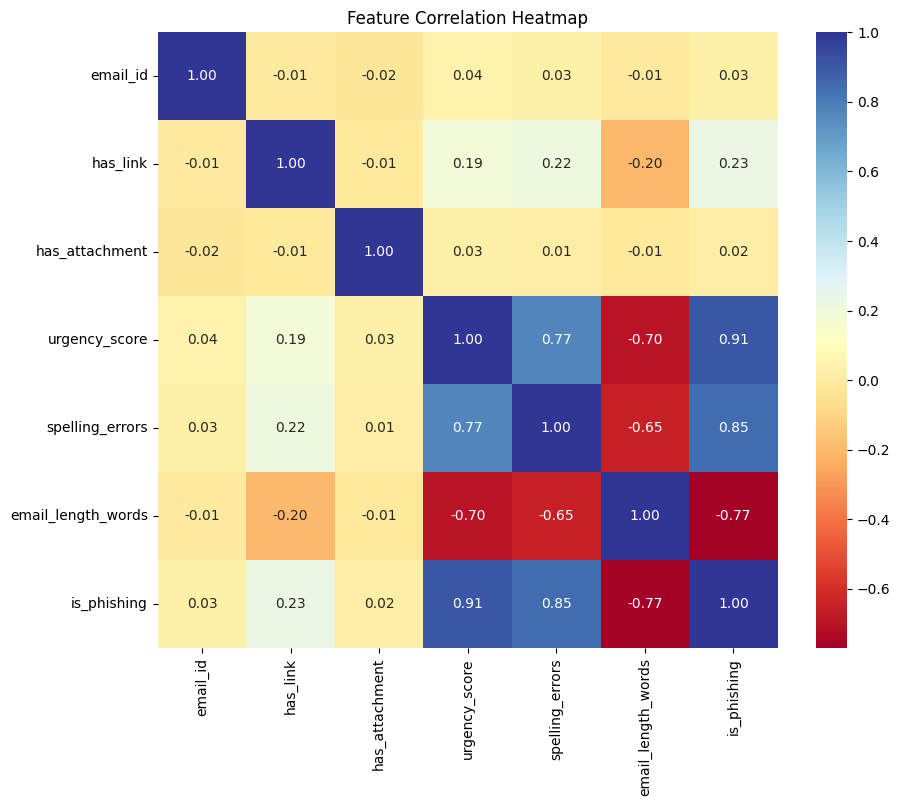

In [24]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

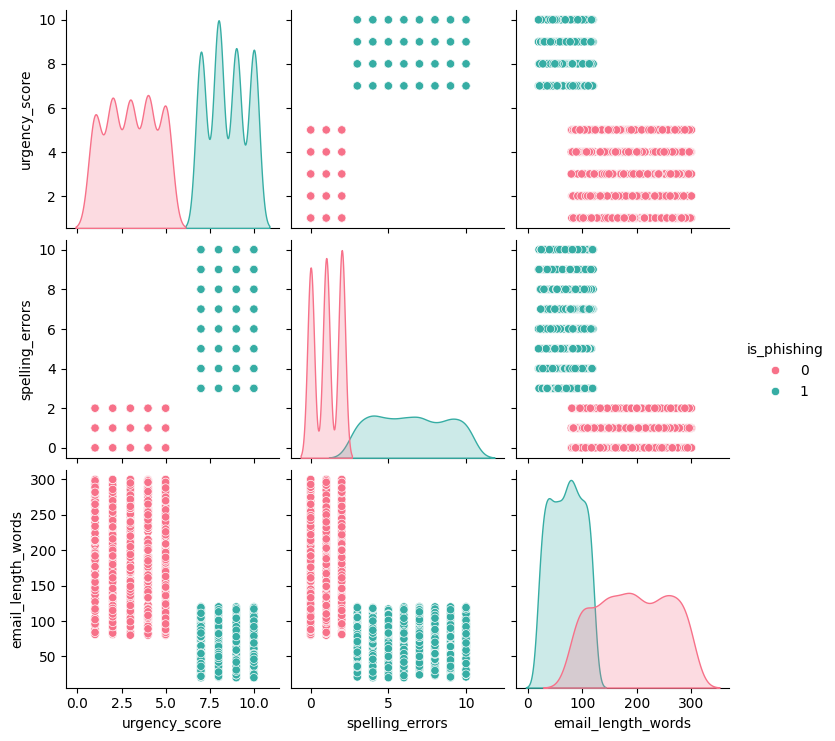

In [25]:
sns.pairplot(
    df,
    hue='is_phishing',
    palette='husl',
    vars=[
        'urgency_score',
        'spelling_errors',
        'email_length_words'
    ]
)

plt.show()

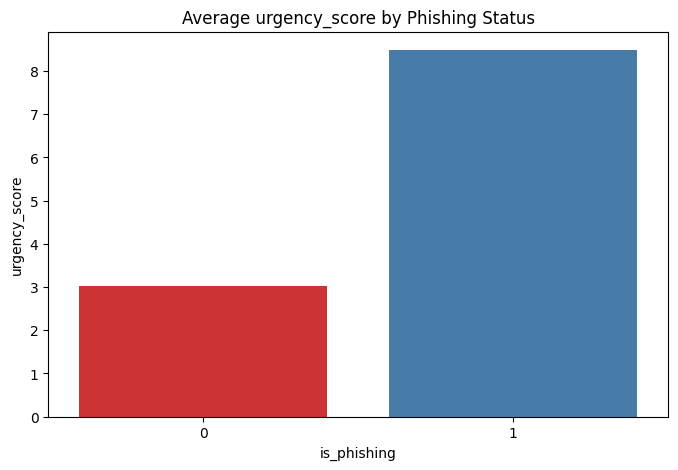

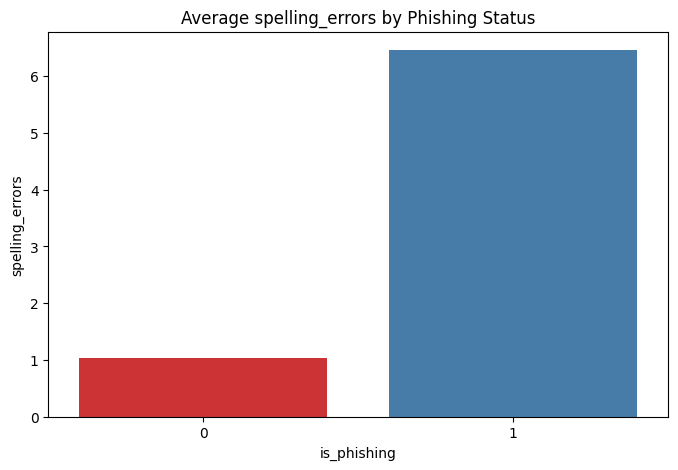

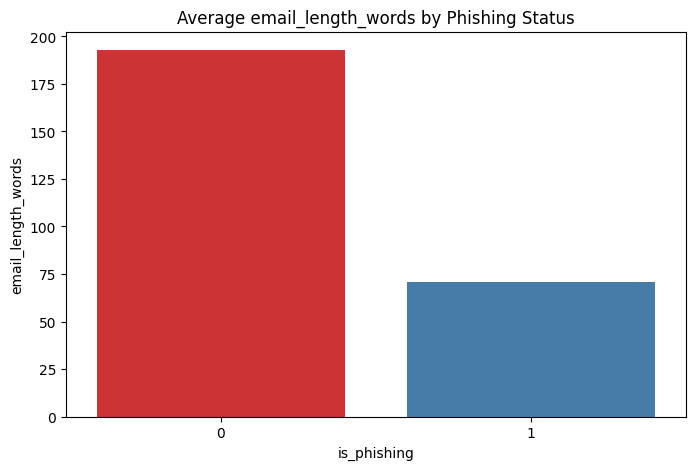

In [26]:
features = [
    'urgency_score',
    'spelling_errors',
    'email_length_words'
]

for feature in features:
    
    plt.figure(figsize=(8,5))
    
    sns.barplot(
        data=df,
        x='is_phishing',
        y=feature,
        palette='Set1',
        errorbar=None
    )
    
    plt.title(f'Average {feature} by Phishing Status')
    plt.show()

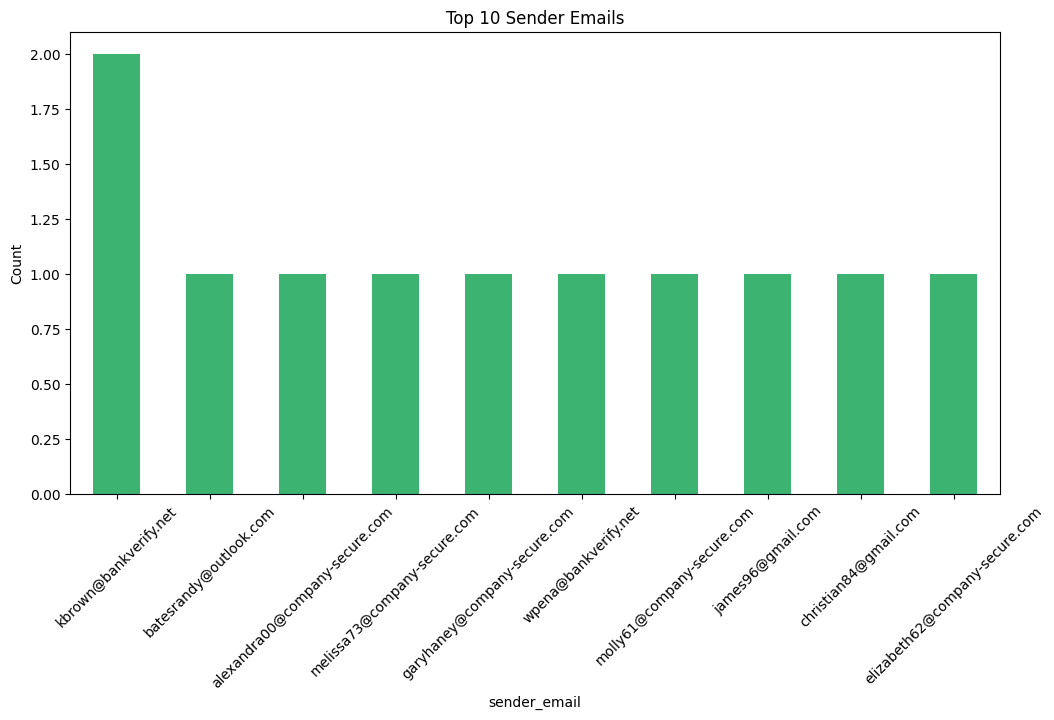

In [27]:
plt.figure(figsize=(12,6))

df['sender_email'].value_counts().head(10).plot(
    kind='bar',
    color='mediumseagreen'
)

plt.title('Top 10 Sender Emails')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

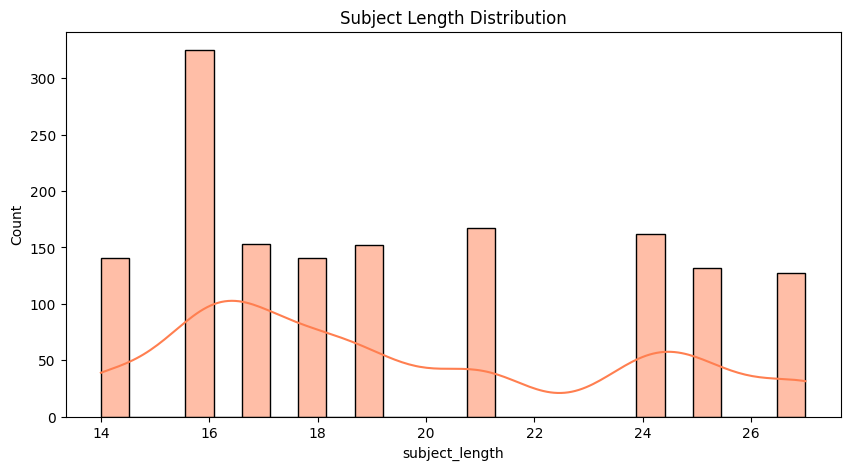

In [28]:
df['subject_length'] = df['subject'].astype(str).apply(len)

plt.figure(figsize=(10,5))

sns.histplot(
    df['subject_length'],
    bins=25,
    color='coral',
    kde=True
)

plt.title('Subject Length Distribution')
plt.show()

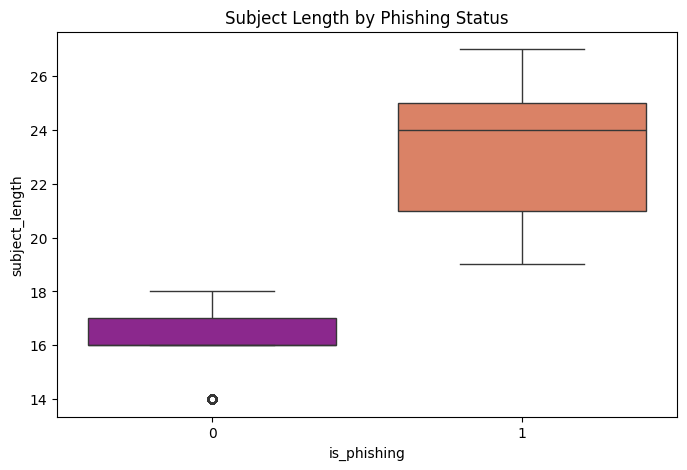

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_phishing',
    y='subject_length',
    palette='plasma'
)

plt.title('Subject Length by Phishing Status')
plt.show()

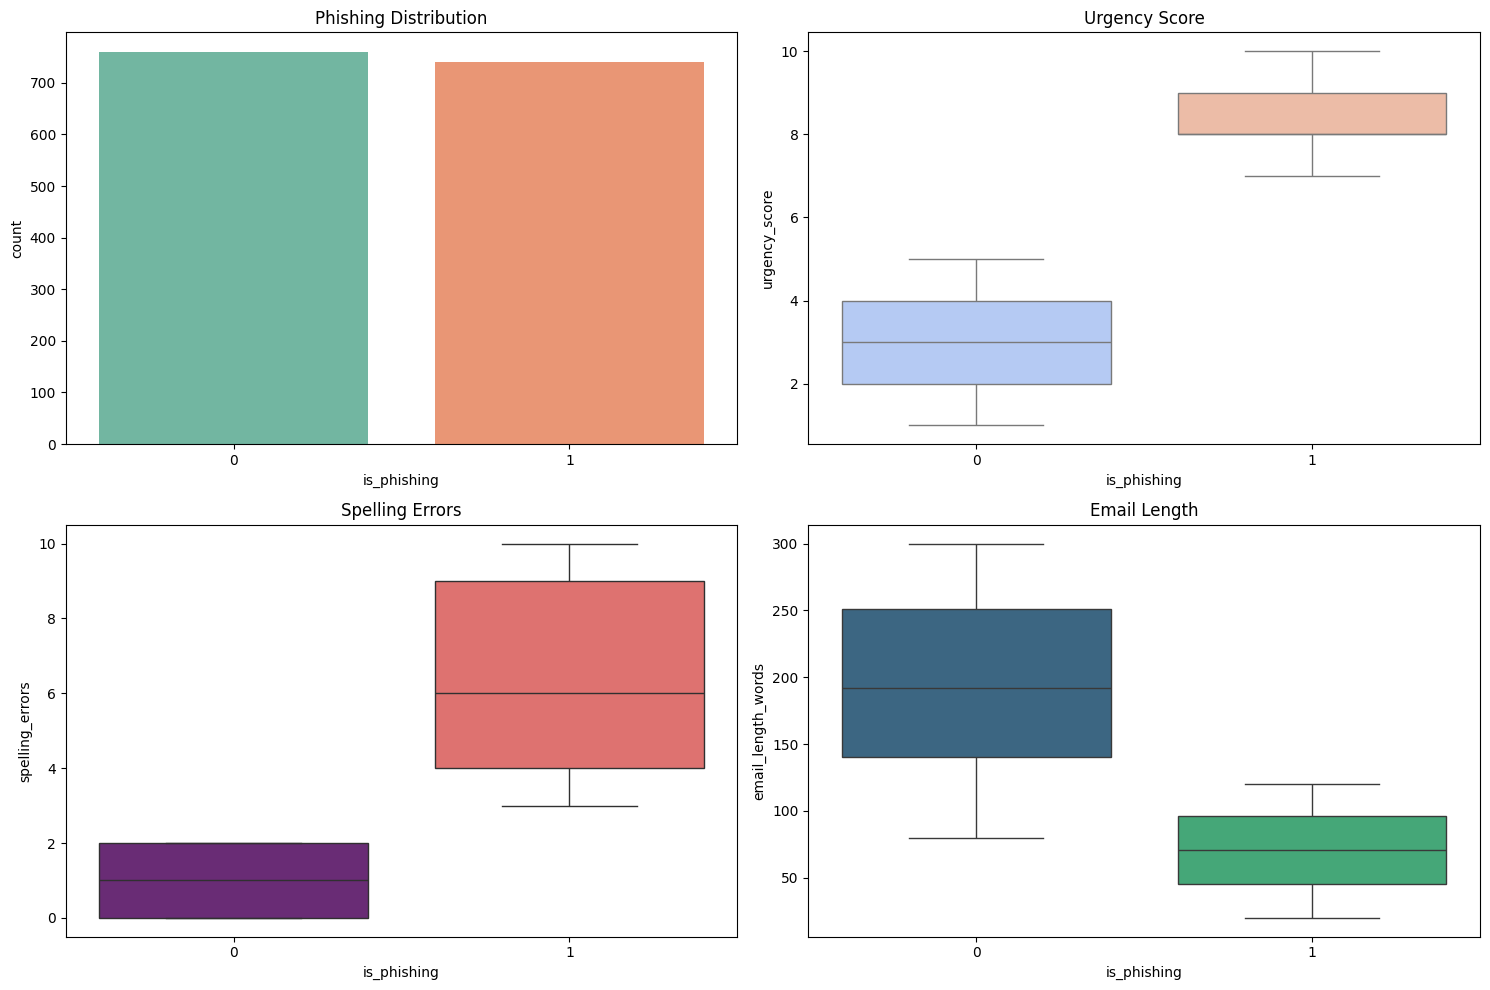

In [30]:
fig, axes = plt.subplots(2,2,figsize=(15,10))

sns.countplot(
    data=df,
    x='is_phishing',
    palette='Set2',
    ax=axes[0,0]
)
axes[0,0].set_title('Phishing Distribution')

sns.boxplot(
    data=df,
    x='is_phishing',
    y='urgency_score',
    palette='coolwarm',
    ax=axes[0,1]
)
axes[0,1].set_title('Urgency Score')

sns.boxplot(
    data=df,
    x='is_phishing',
    y='spelling_errors',
    palette='magma',
    ax=axes[1,0]
)
axes[1,0].set_title('Spelling Errors')

sns.boxplot(
    data=df,
    x='is_phishing',
    y='email_length_words',
    palette='viridis',
    ax=axes[1,1]
)
axes[1,1].set_title('Email Length')

plt.tight_layout()
plt.show()

## Feature engineering

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC


In [32]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 10)


In [33]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 10)


In [34]:
target = "is_phishing"

In [35]:
X = df.drop(columns=[target])
y = df[target]

In [36]:
X = X.drop(columns=["email_id"])

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (1200, 8)
Test Shape : (300, 8)


In [38]:
text_features = ["subject"]

categorical_features = [
    "sender_email"
]

binary_features = [
    "has_link",
    "has_attachment"
]

numeric_features = [
    "urgency_score",
    "spelling_errors",
    "email_length_words"
]

In [39]:
subject_transformer = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=500,
        stop_words='english'
    ))
])

In [40]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [41]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [42]:
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [43]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            'subject',
            TfidfVectorizer(
                max_features=500,
                stop_words='english'
            ),
            'subject'
        ),

        (
            'sender',
            categorical_transformer,
            ['sender_email']
        ),

        (
            'binary',
            binary_transformer,
            binary_features
        ),

        (
            'numeric',
            numeric_transformer,
            numeric_features
        )

    ]
)

In [44]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "Naive Bayes":
        MultinomialNB(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



<Figure size 1000x800 with 0 Axes>

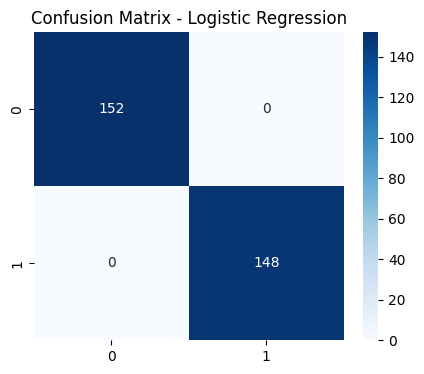

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



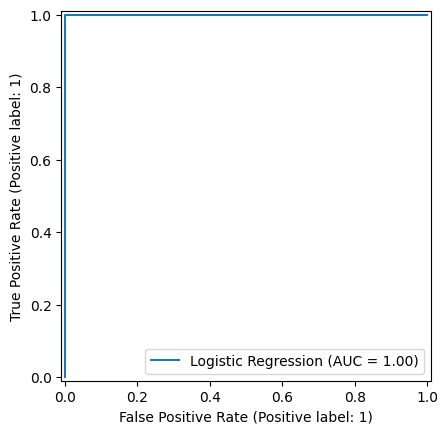

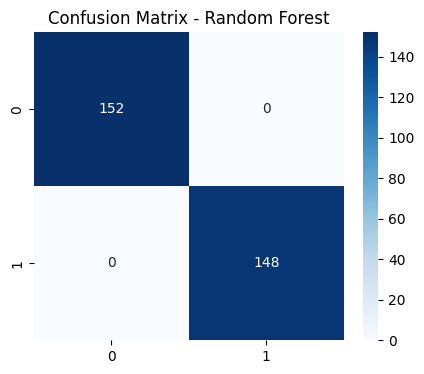

Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



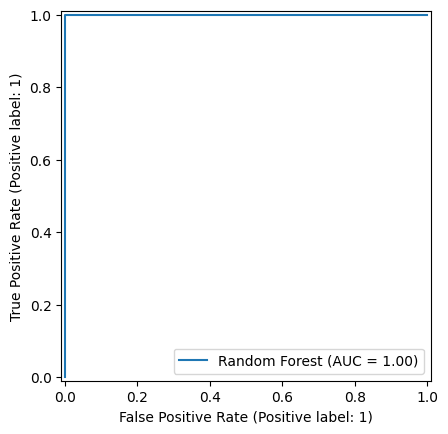

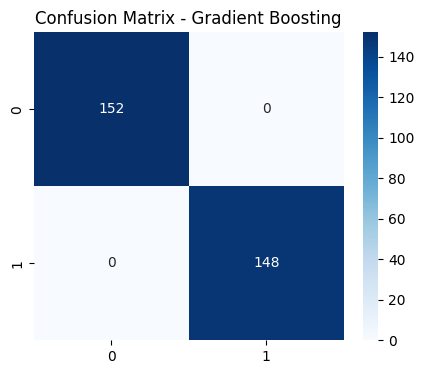

Naive Bayes
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



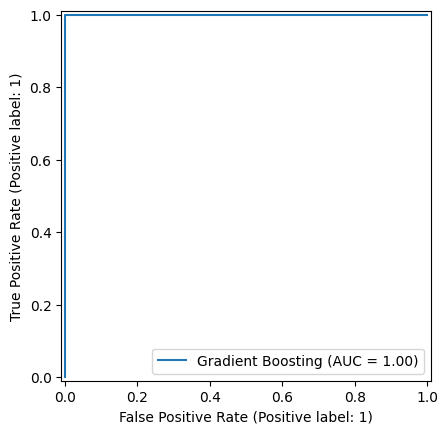

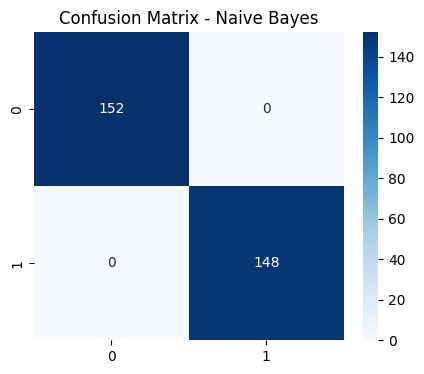

SVM
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       152
           1       0.88      1.00      0.94       148

    accuracy                           0.93       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.94      0.93      0.93       300



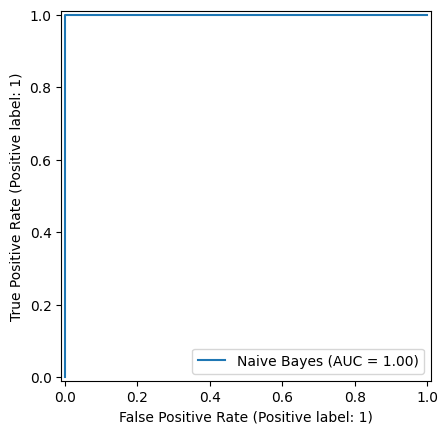

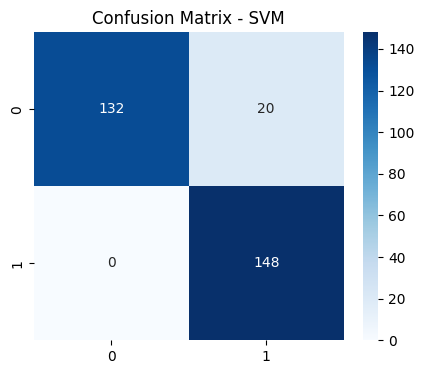

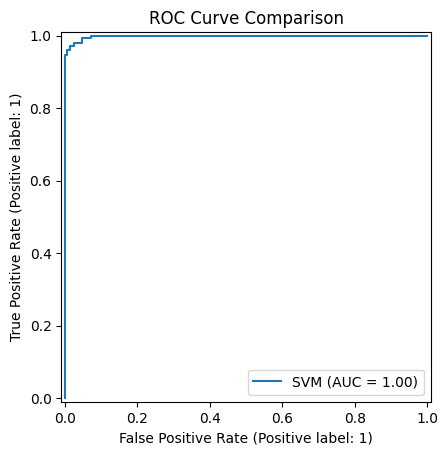

In [45]:
results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    pipe = Pipeline([

        ('preprocessing', preprocessor),

        ('model', model)

    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_prob = pipe.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.title("ROC Curve Comparison")
plt.show()

In [46]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]

)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
0  Logistic Regression  1.000000   1.000000     1.0  1.000000  1.000000
1        Random Forest  1.000000   1.000000     1.0  1.000000  1.000000
2    Gradient Boosting  1.000000   1.000000     1.0  1.000000  1.000000
3          Naive Bayes  1.000000   1.000000     1.0  1.000000  1.000000
4                  SVM  0.933333   0.880952     1.0  0.936709  0.998444


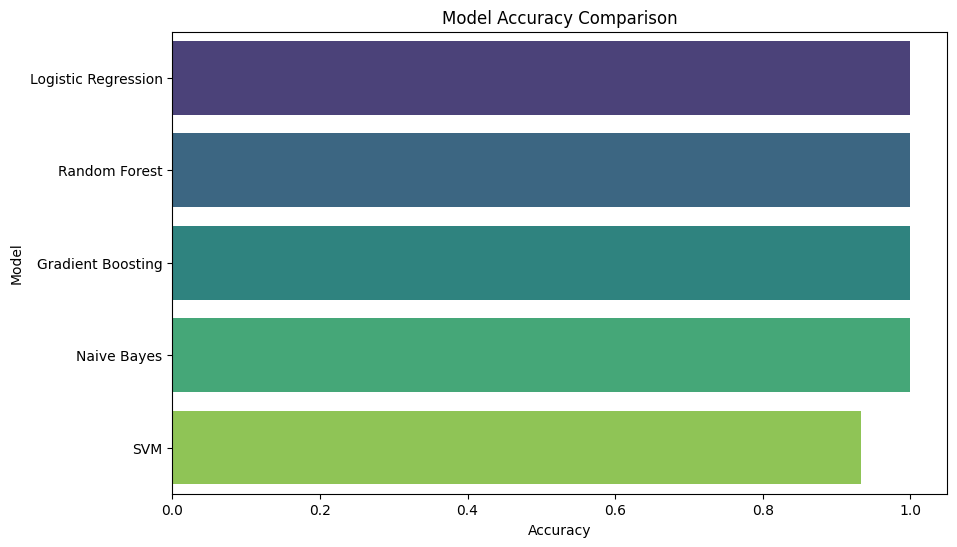

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    palette='viridis'
)

plt.title('Model Accuracy Comparison')
plt.show()

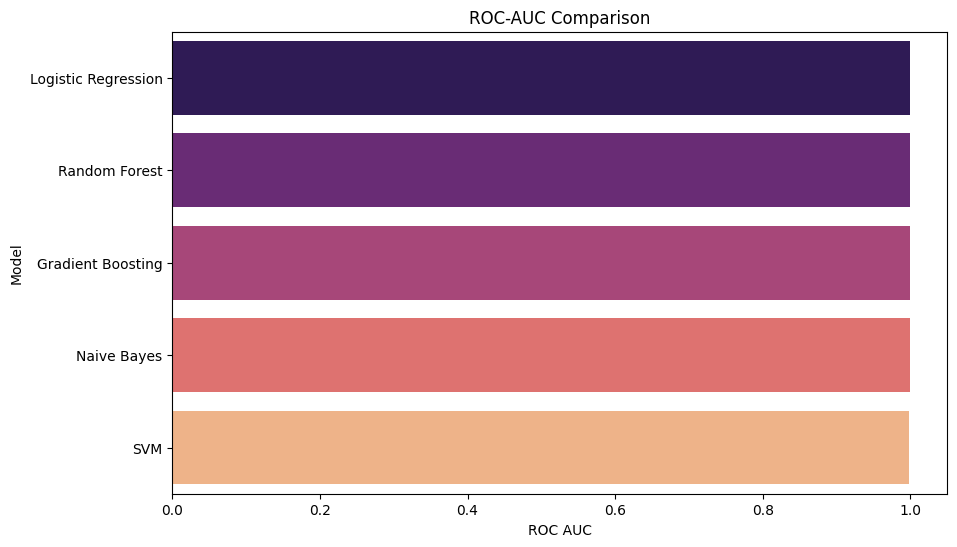

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='ROC AUC',
    y='Model',
    palette='magma'
)

plt.title('ROC-AUC Comparison')
plt.show()

In [49]:
best_model = results_df.iloc[0]

print("\nBest Model")
print(best_model)


Best Model
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
ROC AUC                      1.0
Name: 0, dtype: object


## Thank you...pls upovte!!!!!!!!!!!